In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
DATA_ROOT = "/kaggle/input/nih-chest-xrays"

In [3]:
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

In [4]:
df = pd.read_csv(f"/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv")

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
print(df.shape)

(112120, 12)


In [6]:
df["Target"] = df["Finding Labels"].apply(
    lambda labels: 1 if "Pneumonia" in str(labels).split("|") else 0
)

print(df["Target"].value_counts())

Target
0    110689
1      1431
Name: count, dtype: int64


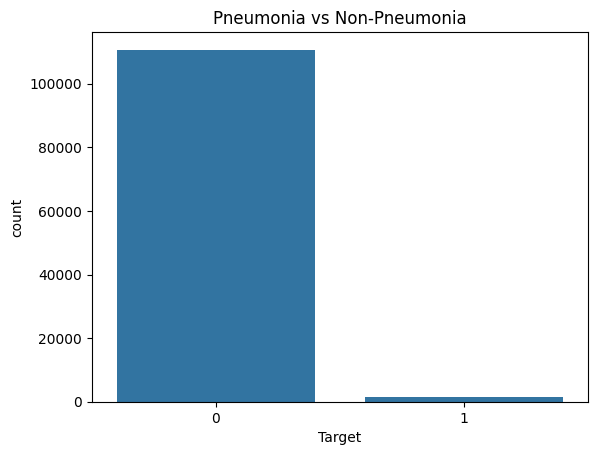

In [7]:
sns.countplot(x="Target", data=df)
plt.title("Pneumonia vs Non-Pneumonia")
plt.show()

In [8]:
pneumonia_df = df[df["Target"] == 1]

non_pneumonia_df = df[df["Target"] == 0].sample(
    n=len(pneumonia_df) * 2,
    random_state=42
)

df_balanced = pd.concat([pneumonia_df, non_pneumonia_df])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced["Target"].value_counts())

Target
0    2862
1    1431
Name: count, dtype: int64


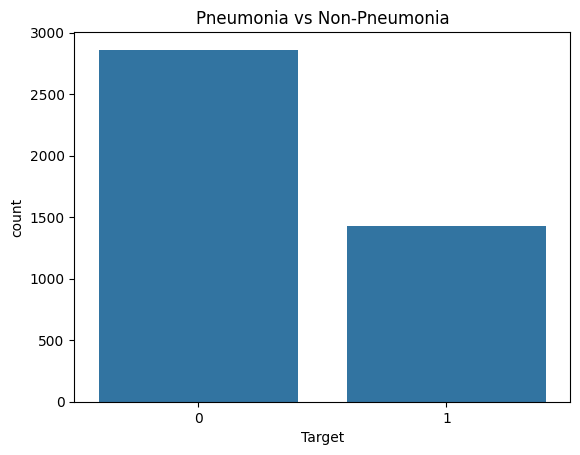

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Target", data=df_balanced)
plt.title("Pneumonia vs Non-Pneumonia")
plt.show()

In [10]:
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

In [11]:
import os

all_images = []

for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.endswith(".png"):
            all_images.append(os.path.join(root, file))

print("Total images found:", len(all_images))
print(all_images[:5])

Total images found: 112120
['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004833_016.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006260_000.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004911_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004186_007.png']


In [12]:
image_path_map = {os.path.basename(x): x for x in all_images}

df_balanced["path"] = df_balanced["Image Index"].map(image_path_map)
df_balanced = df_balanced.dropna(subset=["path"]).reset_index(drop=True)

print(df_balanced.shape)
print(df_balanced["path"].isnull().sum())
df_balanced[["Image Index", "path"]].head()

(4293, 14)
0


,Image Index,path
0,00018472_001.png,/kaggle/input/datasets/organizations/nih-chest...
1,00000116_020.png,/kaggle/input/datasets/organizations/nih-chest...
2,00002003_002.png,/kaggle/input/datasets/organizations/nih-chest...
3,00016490_019.png,/kaggle/input/datasets/organizations/nih-chest...
4,00026050_010.png,/kaggle/input/datasets/organizations/nih-chest...


In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.3,
    stratify=df_balanced["Target"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Target"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3005, 14)
Validation shape: (644, 14)
Test shape: (644, 14)


In [14]:
print("Train target distribution:")
print(train_df["Target"].value_counts())

print("\nValidation target distribution:")
print(val_df["Target"].value_counts())

print("\nTest target distribution:")
print(test_df["Target"].value_counts())

Train target distribution:
Target
0    2003
1    1002
Name: count, dtype: int64

Validation target distribution:
Target
0    429
1    215
Name: count, dtype: int64

Test target distribution:
Target
0    430
1    214
Name: count, dtype: int64


In [15]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [16]:
def clahe_enhancement(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(gray)
    img = cv2.cvtColor(cl, cv2.COLOR_GRAY2RGB)
    return img

In [17]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "Target"]

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        image = clahe_enhancement(image)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [18]:
train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=val_test_transform)
test_dataset = ChestXrayDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train dataset size: 3005
Validation dataset size: 644
Test dataset size: 644
Train batches: 94
Validation batches: 21
Test batches: 21


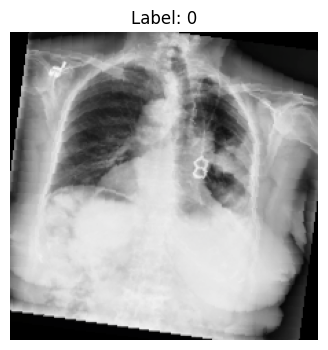

In [19]:
images, labels = next(iter(train_loader))

img = images[0].permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label: {int(labels[0].item())}")
plt.axis("off")
plt.show()

In [20]:
import os

os.makedirs("/kaggle/working/processed_data", exist_ok=True)

train_df.to_csv("/kaggle/working/processed_data/train.csv", index=False)
val_df.to_csv("/kaggle/working/processed_data/val.csv", index=False)
test_df.to_csv("/kaggle/working/processed_data/test.csv", index=False)

print("Saved successfully to /kaggle/working/processed_data")

Saved successfully to /kaggle/working/processed_data


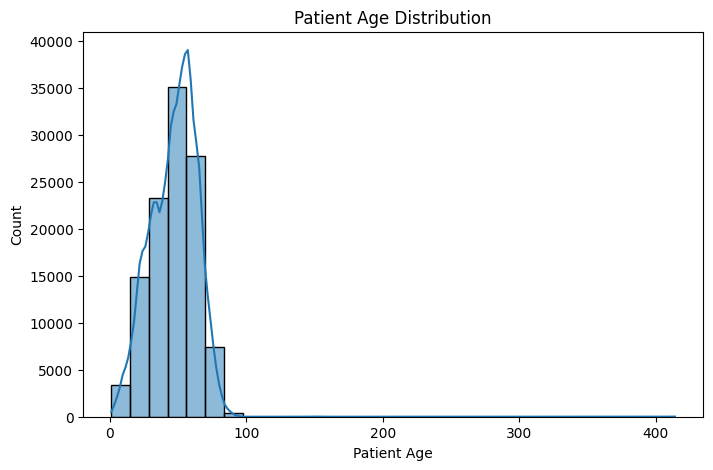

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Patient Age"], bins=30, kde=True)
plt.title("Patient Age Distribution")
plt.show()

print(df["Patient Age"].describe())

Patient Gender
M    63340
F    48780
Name: count, dtype: int64


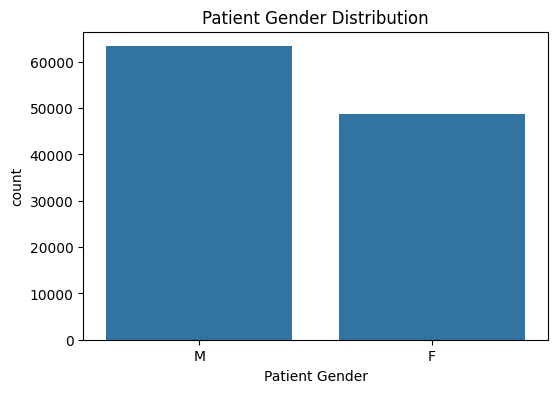

In [22]:
print(df["Patient Gender"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Patient Gender", data=df)
plt.title("Patient Gender Distribution")
plt.show()

View Position
PA    67310
AP    44810
Name: count, dtype: int64


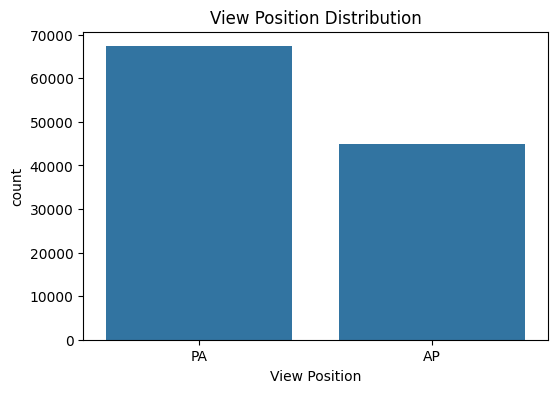

In [23]:
print(df["View Position"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="View Position", data=df)
plt.title("View Position Distribution")
plt.show()

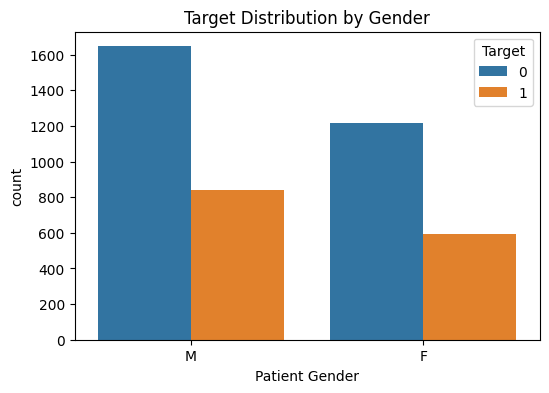

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Patient Gender", hue="Target", data=df_balanced)
plt.title("Target Distribution by Gender")
plt.show()

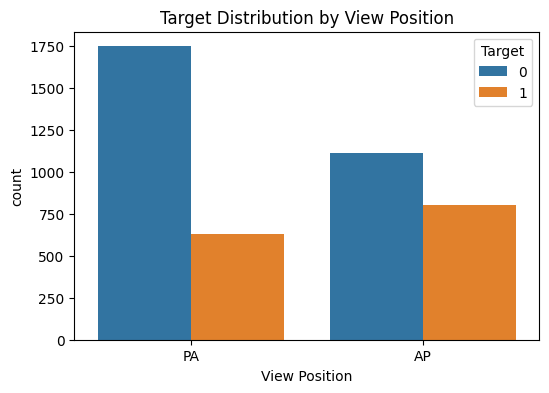

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="View Position", hue="Target", data=df_balanced)
plt.title("Target Distribution by View Position")
plt.show()

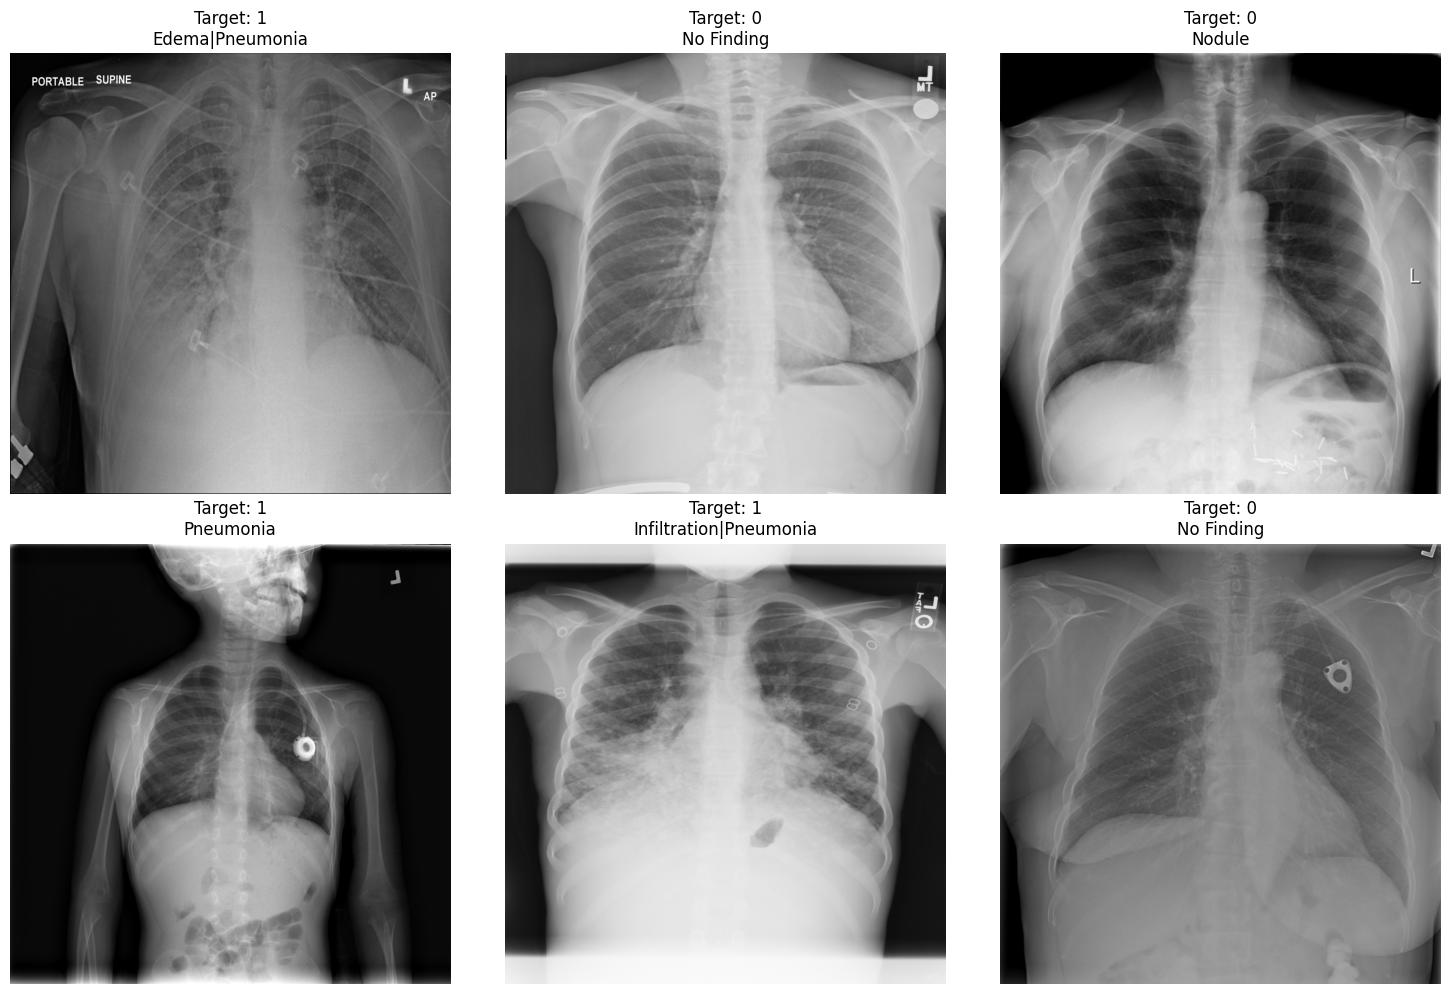

In [26]:
sample_rows = df_balanced.sample(6, random_state=42)

plt.figure(figsize=(15,10))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f'Target: {row["Target"]}\n{row["Finding Labels"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
print("EDA and preprocessing completed successfully.")
print("Final balanced dataset size:", df_balanced.shape)
print("Train set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

EDA and preprocessing completed successfully.
Final balanced dataset size: (4293, 14)
Train set: (3005, 14)
Validation set: (644, 14)
Test set: (644, 14)


In [28]:
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

from torchvision.models import googlenet

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [29]:
model = googlenet(pretrained=True)

model.aux_logits = False

model.fc = nn.Linear(model.fc.in_features,1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 49.7M/49.7M [00:00<00:00, 121MB/s] 


In [30]:
pos_weight = torch.tensor([1.5]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(),lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",patience=2,factor=0.5)

In [31]:
epochs = 20

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step(total_loss)

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 Loss: 0.7568
Epoch 2 Loss: 0.7089
Epoch 3 Loss: 0.6615
Epoch 4 Loss: 0.6190
Epoch 5 Loss: 0.5607
Epoch 6 Loss: 0.4920
Epoch 7 Loss: 0.4406
Epoch 8 Loss: 0.3676
Epoch 9 Loss: 0.3146
Epoch 10 Loss: 0.2828
Epoch 11 Loss: 0.2373
Epoch 12 Loss: 0.2053
Epoch 13 Loss: 0.1707
Epoch 14 Loss: 0.1612
Epoch 15 Loss: 0.1337
Epoch 16 Loss: 0.1384
Epoch 17 Loss: 0.1130
Epoch 18 Loss: 0.1067
Epoch 19 Loss: 0.0999
Epoch 20 Loss: 0.1018


In [32]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).int().cpu().numpy()
        all_predictions.extend(predictions.squeeze())
        all_labels.extend(labels.numpy())

In [33]:
print(classification_report(all_labels,all_predictions))

              precision    recall  f1-score   support

         0.0       0.75      0.79      0.77       429
         1.0       0.54      0.48      0.51       215

    accuracy                           0.69       644
   macro avg       0.65      0.64      0.64       644
weighted avg       0.68      0.69      0.68       644



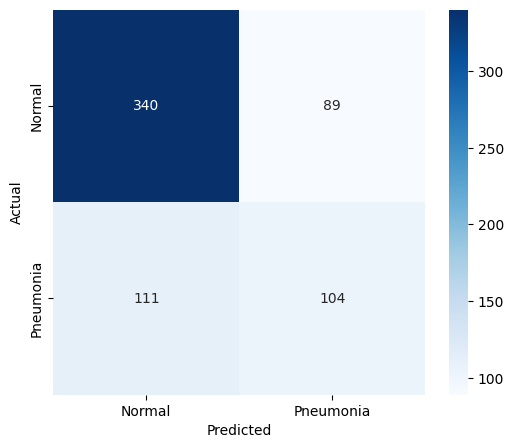

In [35]:
cm = confusion_matrix(all_labels,all_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

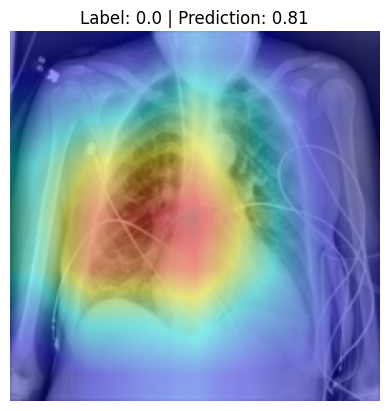

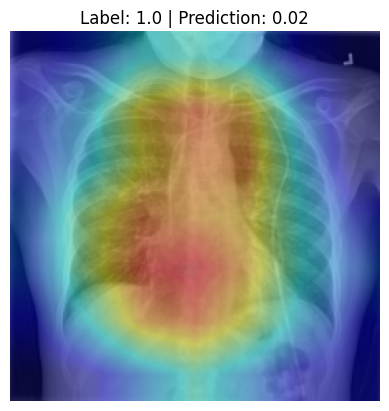

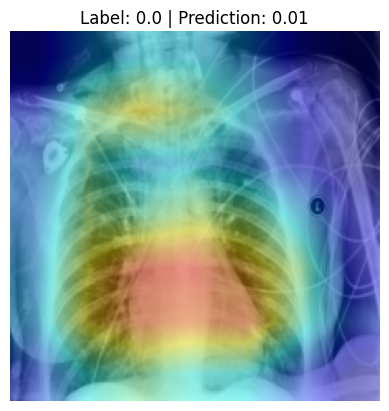

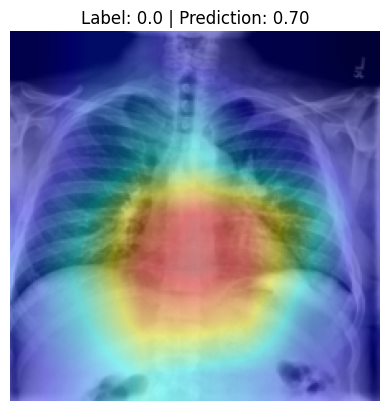

In [37]:
activations = None

def forward_hook(module, input, output):
    global activations
    activations = output
target_layer = model.inception5b
target_layer.register_forward_hook(forward_hook)

def compute_scorecam(model, image):

    model.eval()
    output = model(image)
    prediction = torch.sigmoid(output).item()
    activation_maps = activations[0]
    heatmap = np.zeros((224,224))
    for i in range(activation_maps.shape[0]):
        activation_map = activation_maps[i].cpu().detach().numpy()
        activation_map = cv2.resize(activation_map,(224,224))
        activation_map = (activation_map - activation_map.min()) / (activation_map.max() + 1e-8)
        mask = torch.tensor(activation_map).unsqueeze(0).unsqueeze(0).float().to(device)
        masked_image = image * mask
        score = torch.sigmoid(model(masked_image)).item()
        heatmap += score * activation_map
    heatmap = np.maximum(heatmap,0)
    heatmap = (heatmap - heatmap.min()) / ( heatmap.max() + 1e-8)
    return heatmap

def display_scorecam(image_tensor, heatmap, label, prediction):

    image = image_tensor.cpu().numpy().transpose(1,2,0)

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    image = std * image + mean
    image = np.clip(image,0,1)

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap),cv2.COLORMAP_JET)
    heatmap_color = heatmap_color[...,::-1] / 255.0
    overlay = heatmap_color * 0.4 + image * 0.6
    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)

    plt.title(f"Label: {label} | Prediction: {prediction:.2f}" )
    plt.axis("off")
    plt.show()

images, labels = next(iter(val_loader))

for i in range(4):

    image = images[i].unsqueeze(0).to(device)
    heatmap = compute_scorecam(model, image)
    prediction = torch.sigmoid(model(image)).item()
    display_scorecam(images[i],heatmap,labels[i].item(),prediction)

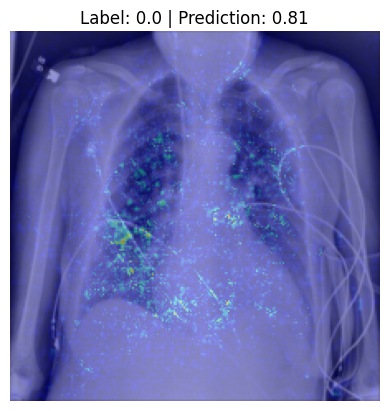

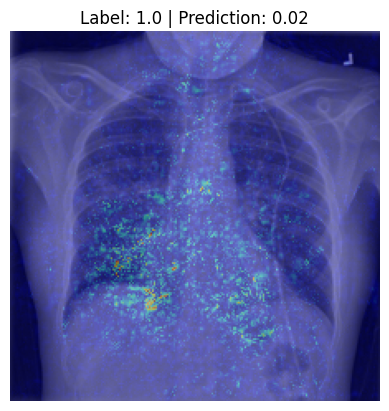

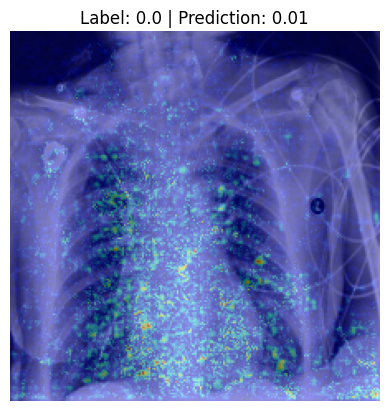

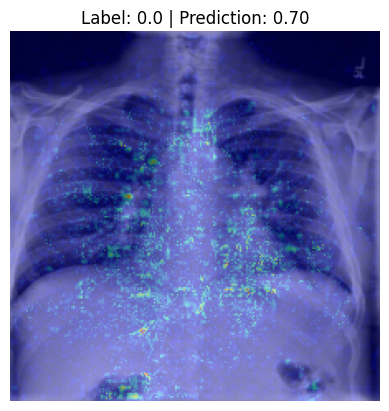

In [39]:
def compute_smoothgrad(model, image, samples=20, noise_level=0.1):
    model.eval()
    smooth_grad = torch.zeros_like(image)
    for i in range(samples):
        noise = torch.randn_like(image) * noise_level
        noisy_image = image + noise
        noisy_image.requires_grad = True
        output = model(noisy_image)
        model.zero_grad()
        output.backward()
        smooth_grad += noisy_image.grad.data
    smooth_grad = smooth_grad / samples
    heatmap = smooth_grad.squeeze().cpu().numpy()
    heatmap = np.mean(np.abs(heatmap), axis=0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)
    return heatmap

def display_smoothgrad(image_tensor, heatmap, label, prediction):

    image = image_tensor.cpu().numpy().transpose(1,2,0)

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    image = std * image + mean
    image = np.clip(image,0,1)

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap),cv2.COLORMAP_JET)
    heatmap_color = heatmap_color[...,::-1] / 255.0
    overlay = heatmap_color * 0.4 + image * 0.6
    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)

    plt.title(f"Label: {label} | Prediction: {prediction:.2f}")
    plt.axis("off")
    plt.show()
images, labels = next(iter(val_loader))
for i in range(4):

    image = images[i].unsqueeze(0).to(device)
    heatmap = compute_smoothgrad(model, image)
    prediction = torch.sigmoid(model(image)).item()
    display_smoothgrad(images[i],heatmap,labels[i].item(),prediction)

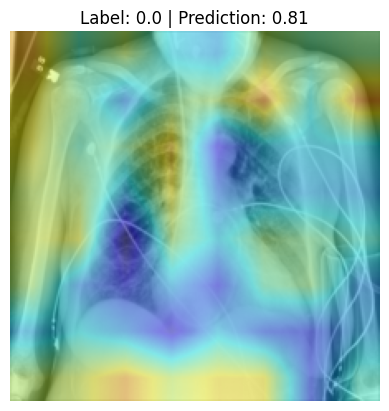

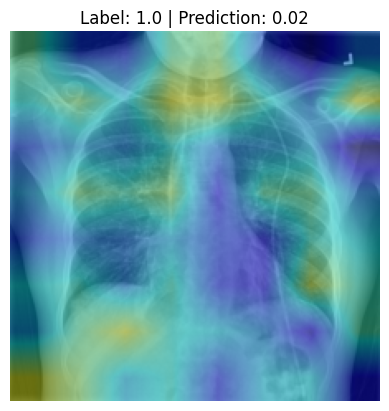

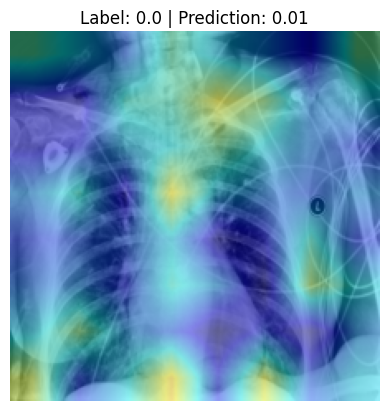

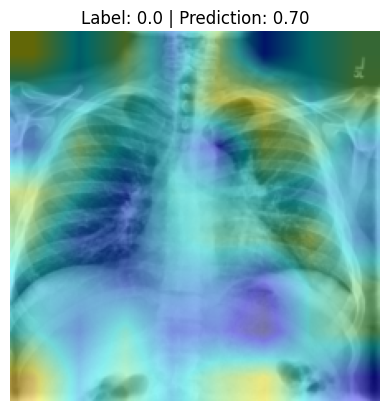

In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

torch.cuda.empty_cache()

def generate_masks(num_masks=50, mask_size=8):

    masks = []
    for i in range(num_masks):
        mask = np.random.rand(mask_size, mask_size) > 0.5
        mask = mask.astype(np.float32)
        mask = cv2.resize(mask, (224,224))
        masks.append(mask)
    return np.array(masks)
def compute_rise(model, image, masks):
    model.eval()
    heatmap = np.zeros((224,224))
    for i in range(len(masks)):
        mask = torch.tensor(
            masks[i]
        ).unsqueeze(0).unsqueeze(0).float().to(device)
        masked_image = image * mask
        output = torch.sigmoid(model(masked_image)).item()

        heatmap += output * masks[i]

    heatmap = heatmap / len(masks)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)

    return heatmap

def display_rise(image_tensor, heatmap, label, prediction):
    image = image_tensor.cpu().numpy().transpose(1,2,0)
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    image = std * image + mean
    image = np.clip(image,0,1)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap),cv2.COLORMAP_JET)

    heatmap_color = heatmap_color[...,::-1] / 255.0
    overlay = heatmap_color * 0.4 + image * 0.6
    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)
    plt.title(f"Label: {label} | Prediction: {prediction:.2f}")

    plt.axis("off")
    plt.show()

masks = generate_masks()
images, labels = next(iter(val_loader))

for i in range(4):

    image = images[i].unsqueeze(0).to(device)
    heatmap = compute_rise(model, image, masks)
    prediction = torch.sigmoid(model(image)).item()

    display_rise(images[i],heatmap,labels[i].item(),prediction)

In [60]:
for module in model.modules():

    if hasattr(module, "_forward_hooks"):
        module._forward_hooks.clear()

    if hasattr(module, "_backward_hooks"):
        module._backward_hooks.clear()

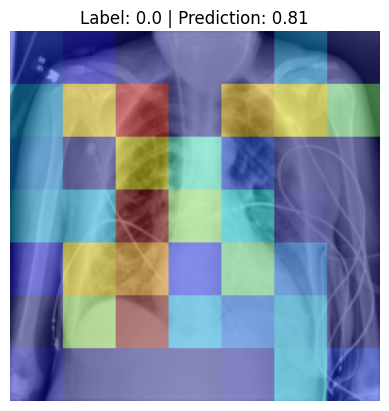

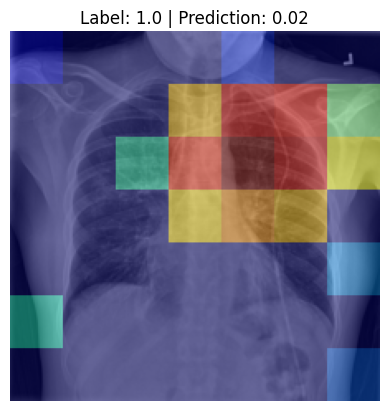

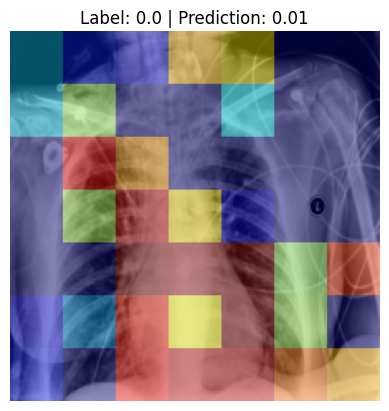

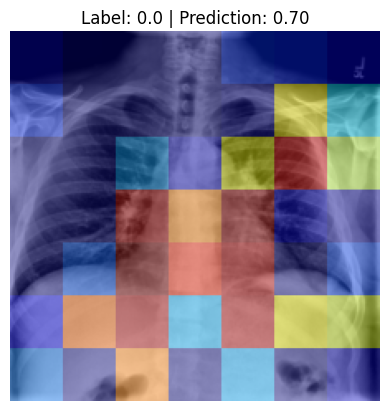

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def compute_occlusion(model, image, patch_size=32):

    model.eval()
    _, _, h, w = image.shape
    original_prediction = torch.sigmoid(model(image)).item()
    heatmap = np.zeros((h,w))
    for y in range(0, h, patch_size):

        for x in range(0, w, patch_size):

            occluded_image = image.clone()

            occluded_image[ :, :, y:y+patch_size, x:x+patch_size] = 0

            occluded_prediction = torch.sigmoid(model(occluded_image)).item()

            importance = ( original_prediction  - occluded_prediction)

            heatmap[y:y+patch_size,x:x+patch_size] = importance

    heatmap = np.maximum(heatmap,0)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)

    return heatmap

def display_occlusion(image_tensor,heatmap,label,prediction):

    image = image_tensor.cpu().numpy().transpose(1,2,0)

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    image = std * image + mean
    image = np.clip(image,0,1)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap),cv2.COLORMAP_JET)

    heatmap_color = heatmap_color[...,::-1] / 255.0

    overlay = heatmap_color * 0.4 + image * 0.6

    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)
    plt.title( f"Label: {label} | Prediction: {prediction:.2f}")
    plt.axis("off")
    plt.show()

images, labels = next(iter(val_loader))

for i in range(4):

    image = images[i].unsqueeze(0).to(device)
    heatmap = compute_occlusion(model,image)

    prediction = torch.sigmoid(model(image)).item()

    display_occlusion(images[i],heatmap,labels[i].item(),prediction)